In [49]:
import numpy as np 
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score

In [50]:
x , y = make_regression(n_samples=100 , n_features=1 , n_informative=1 ,n_targets=1 ,noise=20 , random_state=13)

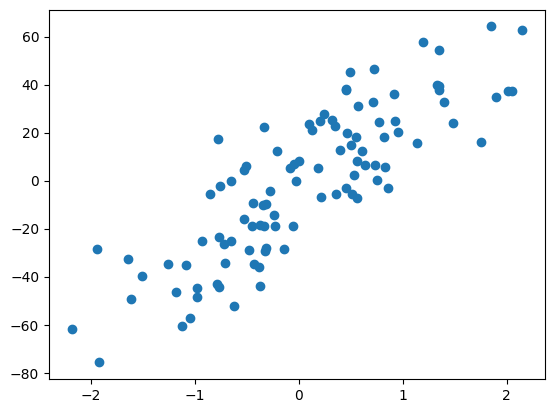

In [51]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [52]:
from sklearn.model_selection import train_test_split

x_train ,x_test , y_train,y_test =  train_test_split(x ,y, test_size= 0.2 , random_state=2)

In [53]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [54]:
lr.coef_

array([28.12597332])

In [55]:
lr.intercept_

np.float64(-2.2710144261783825)

In [56]:
y_pred = lr.predict(x_test)

from sklearn.metrics import r2_score

r2_score(y_test ,y_pred)

0.6345158782661012

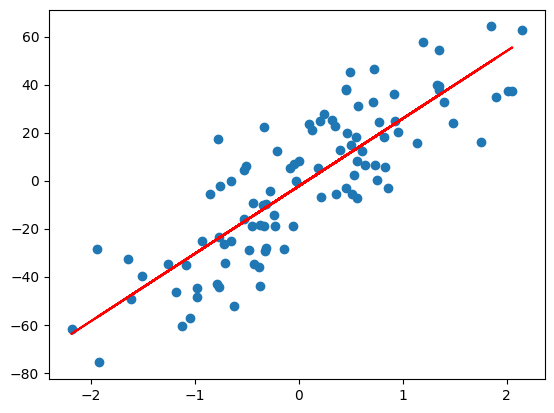

In [57]:
plt.scatter(x,y)
plt.plot(x_train, lr.predict(x_train) , color="red")
plt.show()

In [59]:
class SgdRegressor:

    def __init__(self , learning_rate , epochs ):

        self.b = -120
        self.m = 100
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self , x_train , y_train):

        for i in range(self.epochs):

            slope_b = -2 * np.sum(y_train - self.m * x_train.ravel() - self.b)
            slope_m = -2 * np.sum((y_train - self.m * x_train.ravel() - self.b)*x_train.ravel())


            self . b =  self.b - (self.learning_rate * slope_b)
            self . m =  self.m - (self.learning_rate * slope_m)

        print(self.m ,self.b)

    def predict(self , x_train):
        return self.m*x_train + self.b

In [60]:
gd = SgdRegressor(0.001 ,50)

In [63]:
gd.fit(x_train,y_train)

28.125891702177178 -2.2709893455389714


In [65]:
y_pred = gd.predict(x_test)

In [66]:
r2_score(y_test , y_pred)

0.6345162275128353